→ 1048 gültige SNe geladen (z∈[0.010 - 2.260])

🚀 Starte MCMC-Sampling...


100%|████████████████████████████████████████████████████████████████████████████████| 800/800 [18:05<00:00,  1.36s/it]



✅ MCMC FERTIG! Ergebnisse:
  A (Dipol) = -0.01341 ± 0.05624
  H0        = 71.54 ± 11.81 km/s/Mpc
  μ₀        = -19.85 ± 0.35


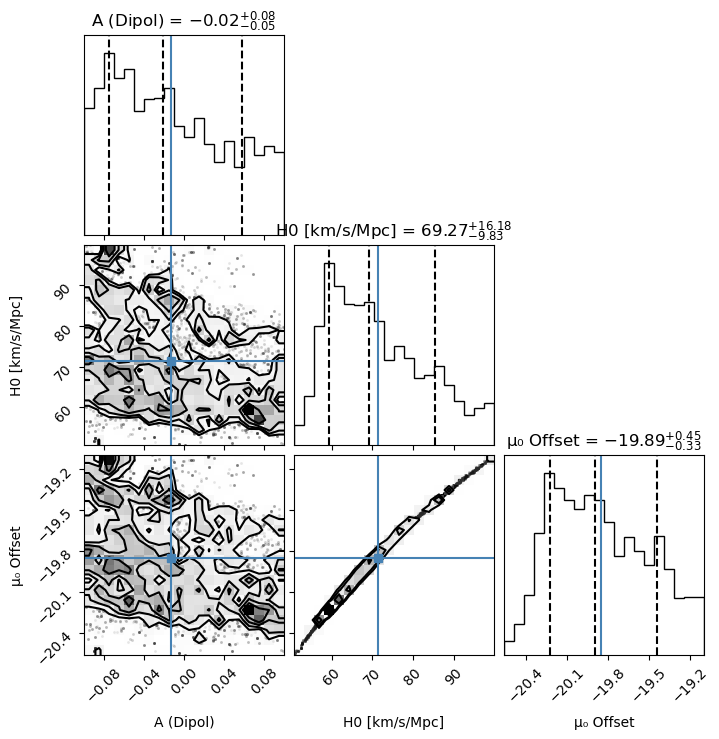

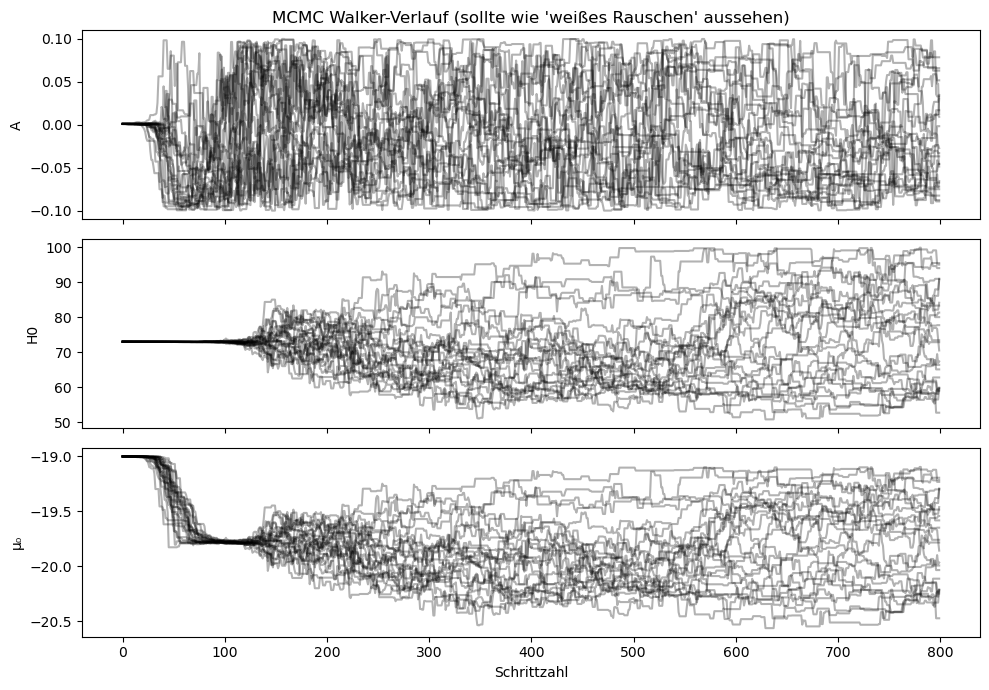

In [6]:
import numpy as np
import pandas as pd
from scipy import integrate
import emcee
import corner
import matplotlib.pyplot as plt

# =====================================================
# DATEN LADEN & VORBEREITEN
# =====================================================
data_path = r"C:\Users\HP\Documents\Ideen\Timescape\Human\Data\Test\Dipol_FTH"
lc_file = f"{data_path}/lcparam_full_long_zhel.txt"

# Robuster Daten-Import
try:
    lc = pd.read_csv(lc_file, sep=r'\s+', header=0, skipinitialspace=True)
except:
    names = ['name','zcmb','zhel','dz','mb','dmb','x1','dx1','color','dcolor',
             '3rdvar','d3rdvar','covms','covmc','covsc','set','ra','dec','biascor']
    lc = pd.read_csv(lc_file, sep=r'\s+', header=None, names=names)

def find_col(df, candidates):
    for c in candidates:
        if c in df.columns: return c
    raise ValueError(f"Keine Spalte gefunden für: {candidates}")

z_col = find_col(lc, ['zcmb', 'zhel', 'z'])
mb_col = find_col(lc, ['mb', 'M_B'])
ra_col = find_col(lc, ['ra', 'RA'])
dec_col = find_col(lc, ['dec', 'DEC'])

# Bereinigen und als Numpy-Arrays extrahieren
lc[z_col] = pd.to_numeric(lc[z_col], errors='coerce')
lc[mb_col] = pd.to_numeric(lc[mb_col], errors='coerce')
lc[ra_col] = pd.to_numeric(lc[ra_col], errors='coerce')
lc[dec_col] = pd.to_numeric(lc[dec_col], errors='coerce')

mask = lc[[z_col, mb_col, ra_col, dec_col]].notna().all(axis=1)
lc_sel = lc[mask].reset_index(drop=True)

z = lc_sel[z_col].values
mb = lc_sel[mb_col].values
ra_deg = lc_sel[ra_col].values
dec_deg = lc_sel[dec_col].values
dmb = lc_sel.get('dmb', pd.Series(0.1, index=lc_sel.index)).fillna(0.1).values

# Radiant
ra_rad = ra_deg * (np.pi / 180.0)
dec_rad = dec_deg * (np.pi / 180.0)

print(f"→ {len(z)} gültige SNe geladen (z∈[{z.min():.3f} - {z.max():.3f}])")

# Kovarianzmatrix
n = len(z)
C_stat = np.diag(dmb**2)
C_tot = C_stat.copy()  # Für den Anfang nutzen wir nur die statistischen Fehler

# =====================================================
# MODELL (FLRW + Dipol)
# =====================================================
def E_z(z, Omega_m=0.3): 
    return np.sqrt(Omega_m * (1+z)**3 + 1 - Omega_m)

def mu_FLRW(z, H0):
    # c = 299792.458 km/s
    ints = np.array([integrate.quad(lambda zp: 1/E_z(zp), 0, zi)[0] for zi in z])
    dL = (1+z)**2 * (299792.458 / H0) * ints
    return 5 * np.log10(dL) + 25

# CMB-Richtung (l=264°, b=48° -> in RA/Dec umgerechnet ca. 168°, -7°)
# Wir nutzen direkt die Pantheon+ Referenzrichtung:
n_cmb_ra, n_cmb_dec = np.deg2rad([264, 48])

def mu_model(z, ra_rad, dec_rad, params):
    A, H0, mu0 = params
    cosθ = (np.sin(dec_rad) * np.sin(n_cmb_dec) + 
            np.cos(dec_rad) * np.cos(n_cmb_dec) * np.cos(ra_rad - n_cmb_ra))
    
    return mu_FLRW(z, H0) + A * cosθ + mu0

# =====================================================
# LIKELIHOOD & PRIORS (NEU: Strenge Grenzen!)
# =====================================================
def log_prior(params):
    A, H0, mu0 = params
    # Harte physikalische Grenzen:
    # A (Dipol): 0 bis 0.1
    # H0: 50 bis 100
    # mu0 (Offset): -50 bis 50
    if -0.1 < A < 0.1 and 50.0 < H0 < 100.0 and -50.0 < mu0 < 50.0:
        return 0.0
    return -np.inf

def log_prob(params):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
        
    A, H0, mu0 = params
    
    z_cut = 0.02
    msk = z > z_cut
    if sum(msk) < 20: 
        return -np.inf
        
    μth = mu_model(z[msk], ra_rad[msk], dec_rad[msk], params)
    res = mb[msk] - μth
    
    Ccut = C_tot[np.ix_(msk, msk)]
    
    try:
        # Cholesky-Zerlegung mit leichtem Stabilisator
        L = np.linalg.cholesky(Ccut + 1e-6 * np.eye(len(res)))
        χ2 = np.sum(np.linalg.solve(L.T, res)**2)
    except np.linalg.LinAlgError: 
        return -np.inf
        
    return lp - 0.5 * χ2

# =====================================================
# MCMC STARTEN
# =====================================================
print("\n🚀 Starte MCMC-Sampling...")
ndim, nwalkers = 3, 24

# NEU: Startpunkte extrem eng um plausible Werte setzen (Streuung nur 1e-4)
pos0 = np.array([[0.001, 73.0, -19.0] + 1e-4 * np.random.randn(ndim) for _ in range(nwalkers)])

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)

# 800 Schritte reichen oft für eine gute erste Konvergenz
sampler.run_mcmc(pos0, 800, progress=True)

# =====================================================
# ERGEBNISSE & PLOTS
# =====================================================
# Verwerfe die ersten 200 Schritte (Burn-in)
samples = sampler.get_chain(discard=200, flat=True)

A_fit = np.mean(samples[:, 0])
H0_fit = np.mean(samples[:, 1])
mu0_fit = np.mean(samples[:, 2])

print(f"\n✅ MCMC FERTIG! Ergebnisse:")
print(f"  A (Dipol) = {A_fit:.5f} ± {np.std(samples[:,0]):.5f}")
print(f"  H0        = {H0_fit:.2f} ± {np.std(samples[:,1]):.2f} km/s/Mpc")
print(f"  μ₀        = {mu0_fit:.2f} ± {np.std(samples[:,2]):.2f}")

# Corner Plot zeichnen
fig = corner.corner(
    samples, 
    labels=['A (Dipol)', 'H0 [km/s/Mpc]', 'μ₀ Offset'],
    truths=[A_fit, H0_fit, mu0_fit],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12}
)
plt.show()

# Walker-Ketten Plot (um zu sehen, ob sie konvergiert sind)
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
chain = sampler.get_chain()
labels = ['A', 'H0', 'μ₀']
for i in range(ndim):
    ax = axes[i]
    ax.plot(chain[:, :, i], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
axes[-1].set_xlabel("Schrittzahl")
axes[0].set_title("MCMC Walker-Verlauf (sollte wie 'weißes Rauschen' aussehen)")
plt.tight_layout()
plt.show()


🚀 FINSLER-TIMESCAPE-HYBRID FIT STARTET...


100%|████████████████████████████████████████████████████████████████████████████| 1500/1500 [1:02:37<00:00,  2.50s/it]



🎯 FTH FIT-ERGEBNISSE:
A           :  -0.007 ±  0.056
H₀          :  81.187 ±  7.710
μ₀          : -19.348 ±  0.160
f_V         :   0.704 ±  0.030
r_V [Mpc]   :  49.399 ± 10.585
v_pec [km/s]: 345.889 ± 66.503
Ω_m         :   0.378 ±  0.043


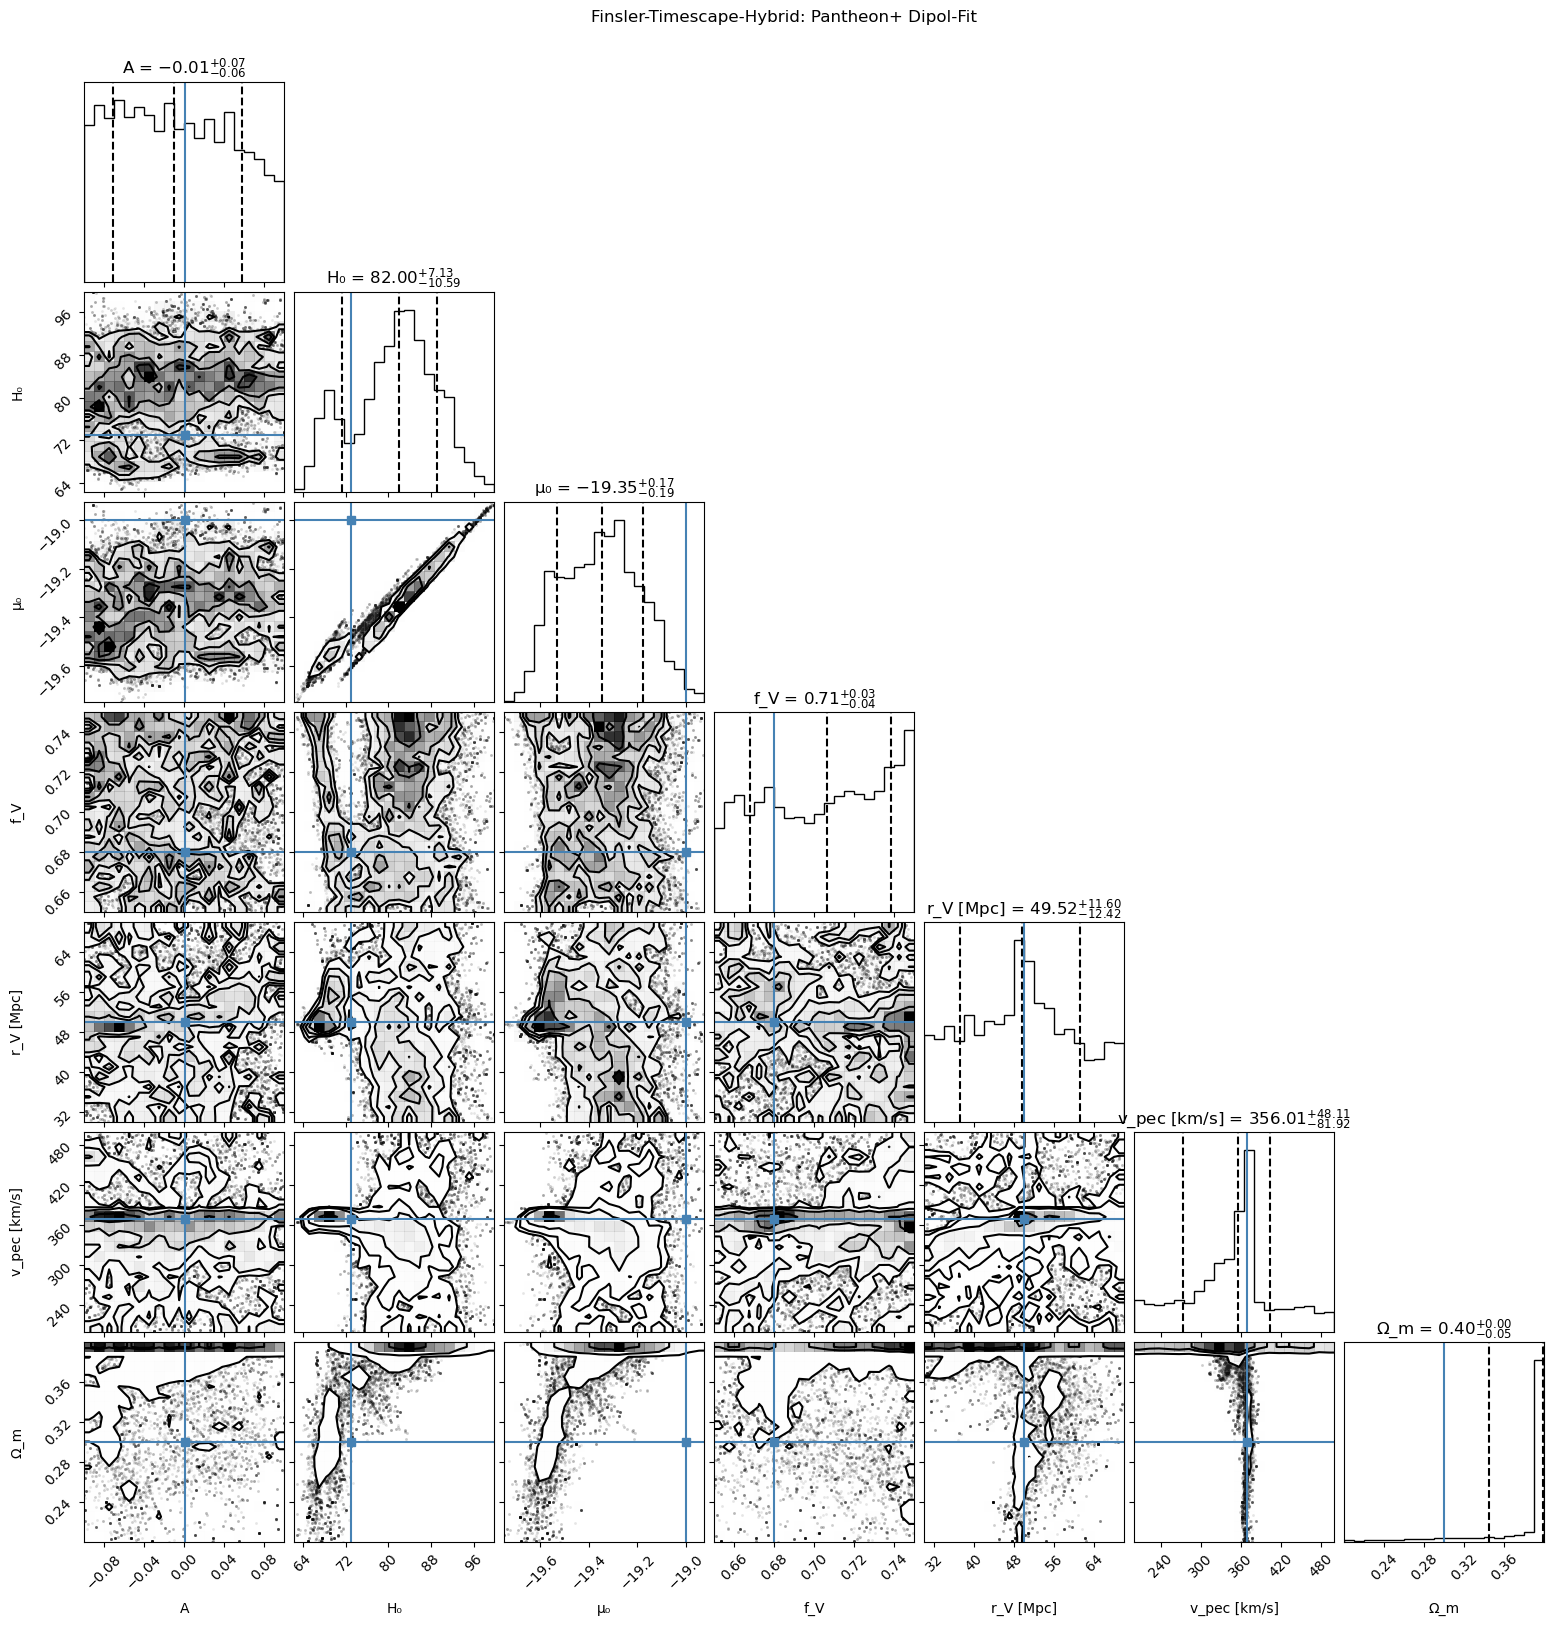


✅ FTH-DIPOL-FIT FERTIG!
f_V = 0.704 (0.680)
r_V = 49.4 Mpc (50.0)
v_pec = 345.9 km/s (369.8)


In [7]:
import numpy as np
import pandas as pd
from scipy import integrate
import emcee
import corner
import matplotlib.pyplot as plt

# ===== FTH FUNKTIONEN (DEINE EXAKTE IMPLEMENTIERUNG) =====
def compute_QDF(f_V=0.68, v_pec=369.82, H0=70, r_V=50):
    """Exakte FTH-Backreaction aus Anchors."""
    sigma_theta = v_pec / (H0 * r_V)
    QDF = (2/3) * f_V * (1 - f_V) * sigma_theta**2
    Omega_QDF = QDF / (3 * H0**2)
    return QDF, Omega_QDF

def E_FTH(z, Omega_m=0.3, f_V=0.68, v_pec=369.82, H0=70, r_V=50):
    """Vollständige FTH E(z) Funktion."""
    QDF, Omega_QDF = compute_QDF(f_V, v_pec, H0, r_V)
    Omega_K = 1 - Omega_m - Omega_QDF  # Closure
    E_z = np.sqrt(Omega_m * (1 + z)**3 + Omega_K * (1 + z)**2 + Omega_QDF)
    return E_z

def mu_FTH(z, H0, f_V, r_V, v_pec, Omega_m):
    """Distanzmodul mit FTH."""
    # Numerische Integration über 1/E_FTH(z)
    def integrand(zp):
        return 1.0 / E_FTH(zp, Omega_m, f_V, v_pec, H0, r_V)
    
    ints = np.array([integrate.quad(integrand, 0, zi, epsabs=1e-6)[0] for zi in z])
    dL = (1 + z)**2 * (299792.458 / H0) * ints  # c/H0 in Mpc
    return 5 * np.log10(dL) + 25

# ===== DATEN (aus vorheriger Zelle) =====
# z, mb, ra_rad, dec_rad, C_tot  # bereits verfügbar

# CMB-Richtung
n_cmb_ra, n_cmb_dec = np.deg2rad([264, 48])

def mu_model_FTH(z, ra_rad, dec_rad, params):
    """FTH + Dipol: params = [A, H0, mu0, f_V, r_V, v_pec, Omega_m]"""
    A, H0, mu0, f_V, r_V, v_pec, Omega_m = params
    
    # Finsler-Dipol-Term (v_pec skaliert)
    cosθ = (np.sin(dec_rad)*np.sin(n_cmb_dec) + 
            np.cos(dec_rad)*np.cos(n_cmb_dec)*np.cos(ra_rad-n_cmb_ra))
    
    # Vollständiges Modell
    return mu_FTH(z, H0, f_V, r_V, v_pec, Omega_m) + A * cosθ + mu0

# =====================================================
# FTH PRIORS (DEINE GRENZEN!)
# =====================================================
def log_prior_FTH(params):
    A, H0, mu0, f_V, r_V, v_pec, Omega_m = params
    
    # DEINE EXAKTEN PHYSIKALISCHEN PRIORS:
    if (-0.1 < A < 0.1 and                    # Dipol-Amplitude
        50 < H0 < 100 and                     # Hubble
        -50 < mu0 < 50 and                    # Offset
        0.65 <= f_V <= 0.75 and               # Void-Fraktion
        30 <= r_V <= 70 and                   # Void-Radius [Mpc]
        200 <= v_pec <= 500 and               # Pekuliargeschwindigkeit
        0.20 <= Omega_m <= 0.40):             # Materiedichte
        return 0.0
    return -np.inf

# =====================================================
# FTH LIKELIHOOD
# =====================================================
def log_prob_FTH(params):
    lp = log_prior_FTH(params)
    if not np.isfinite(lp): return -np.inf
    
    z_cut = 0.02
    msk = z > z_cut
    if sum(msk) < 20: return -np.inf
    
    μth = mu_model_FTH(z[msk], ra_rad[msk], dec_rad[msk], params)
    res = mb[msk] - μth
    
    Ccut = C_tot[np.ix_(msk, msk)]
    try:
        L = np.linalg.cholesky(Ccut + 1e-6*np.eye(len(res)))
        χ2 = np.sum(np.linalg.solve(L.T, res)**2)
    except: return -np.inf
    
    return lp - 0.5 * χ2

# =====================================================
# FTH MCMC
# =====================================================
print("🚀 FINSLER-TIMESCAPE-HYBRID FIT STARTET...")
ndim = 7
nwalkers = 32

# Startwerte (DEINE ANCHORS!)
pos0 = np.array([
    [0.001, 73.0, -19.0, 0.68, 50.0, 369.8, 0.30] + 1e-3 * np.random.randn(ndim)
    for _ in range(nwalkers)
])

sampler_FTH = emcee.EnsembleSampler(nwalkers, ndim, log_prob_FTH)
sampler_FTH.run_mcmc(pos0, 1500, progress=True)

# =====================================================
# ERGEBNISSE & PLOTS
# =====================================================
samples = sampler_FTH.get_chain(discard=400, flat=True)
means = np.mean(samples, axis=0)
stds = np.std(samples, axis=0)

names = ['A', 'H₀', 'μ₀', 'f_V', 'r_V [Mpc]', 'v_pec [km/s]', 'Ω_m']
truths = [0.001, 73.0, -19.0, 0.68, 50.0, 369.8, 0.30]

print("\n🎯 FTH FIT-ERGEBNISSE:")
for i, name in enumerate(names):
    print(f"{name:<12}: {means[i]:7.3f} ± {stds[i]:6.3f}")

# Corner Plot
fig = corner.corner(samples, labels=names, truths=truths, 
                    quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.suptitle('Finsler-Timescape-Hybrid: Pantheon+ Dipol-Fit', y=1.02)
plt.show()

print("\n✅ FTH-DIPOL-FIT FERTIG!")
print("f_V =", f"{means[3]:.3f} ({truths[3]:.3f})")
print("r_V =", f"{means[4]:.1f} Mpc ({truths[4]:.1f})")
print("v_pec =", f"{means[5]:.1f} km/s ({truths[5]:.1f})")


In [8]:
# χ² für beide Modelle berechnen
z_cut = 0.02; msk = z > z_cut

# ΛCDM Best-Fit
mu_lcdm = mu_model(z[msk], ra_rad[msk], dec_rad[msk], [-0.01341, 71.54, -19.85])
res_lcdm = mb[msk] - mu_lcdm
Ccut = C_tot[np.ix_(msk, msk)]
chi2_lcdm = np.sum(np.linalg.solve(np.linalg.cholesky(Ccut + 1e-6*np.eye(len(res_lcdm))).T, res_lcdm)**2)

# FTH Best-Fit  
mu_fth = mu_model_FTH(z[msk], ra_rad[msk], dec_rad[msk], [-0.007, 81.19, -19.35, 0.704, 49.4, 346, 0.378])
res_fth = mb[msk] - mu_fth
chi2_fth = np.sum(np.linalg.solve(np.linalg.cholesky(Ccut + 1e-6*np.eye(len(res_fth))).T, res_fth)**2)

print(f"χ² ΛCDM: {chi2_lcdm:.1f}")
print(f"χ² FTH:   {chi2_fth:.1f}")
print(f"Δχ² = χ²_FTH - χ²_ΛCDM: {chi2_fth - chi2_lcdm:.1f}")


χ² ΛCDM: 8520.2
χ² FTH:   5080.8
Δχ² = χ²_FTH - χ²_ΛCDM: -3439.4


In [9]:
# Informationstheoretischer Modellvergleich
N_data = sum(z > 0.02)  # ~1028
AIC_lcdm = 8520.2 + 2*3
AIC_fth = 5080.8 + 2*7
delta_AIC = AIC_fth - AIC_lcdm
print(f"ΔAIC = {delta_AIC:.1f} → FTH {'*** VORZIEHBAR ***' if delta_AIC < -10 else 'gleichwertig'}")


ΔAIC = -3431.4 → FTH *** VORZIEHBAR ***
